# <center><font color="green">Desafío-Regresión Lineal</font></center>

Este conjunto de datos es un registro de las ventas en el mercado de 7 especies comunes
de peces diferentes. Con este conjunto de datos, se busca realizar un modelo predictivo
utilizando datos adecuados para máquinas y estimar el peso de los peces basándose en la
longitud y ancho del pez.
El conjunto de datos incluye información sobre varias dimensiones del pez, que se utilizan
para predecir su peso. Cada fila en el conjunto de datos representa una entrada de un pez
individual y contiene varias columnas con información relevante. Las dimensiones del pez y
otros atributos en el conjunto de datos podrían incluir:
 - Species: La especie del pez.
 - Weight: El peso del pez, que es la variable que se intenta predecir.
 - Length1, Length2, Length3: Diferentes longitudes del pez.
 - Height: Altura del pez.
 - Width: Ancho del pez.

Los datos en este archivo permiten realizar análisis estadísticos y modelado predictivo para
determinar cómo las dimensiones del pez están relacionadas con su peso. Esto puede ser
útil en la industria pesquera y en la investigación científica para comprender mejor las
relaciones entre las características físicas de los peces y su peso. Para esto se te solicita:
 1. Crea una nueva columna que incluya el volumen de pez, asumiéndolo como un
cilindro. Para un cilindro con una base circular, el área de la base (A) es igual a πr²,
donde "r" es el radio de la base del cilindro, y la altura (h) es la distancia entre las dos
bases circulares.
 2. Verifica la correlación posible entre las variables, numérica y gráficamente.
¿Aumenta la correlación entre el peso y longitudes de los peces, altura y ancho al
añadir el volumen? Explica.
 3. Construye un modelo de regresión lineal que relacione el volumen y el peso de los
peces. Realiza una breve evaluación del modelo y grafícalo.
 4. ¿Qué sucede si aplicas el modelo anterior por separado a cada especie de peces?
Explica.
 5. Construye un modelo de regresión que relacione dos o más variables con el peso de
los peces. Realiza una breve evaluación del modelo.

In [1]:
# Primero vamos a importar pandas.
import pandas as pd

# Creamos el dataframe usando 'pd.read_csv()'.
df= pd.read_csv('Fish.csv',delimiter=',')

# Mostramos el dataframe creado.
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [2]:
# Mostramos un resumen estadístico.
df.describe(include="all")

,Species,Weight,Length1,Length2,Length3,Height,Width
count,159,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
unique,7,NaN,NaN,NaN,NaN,NaN,NaN
top,Perch,NaN,NaN,NaN,NaN,NaN,NaN
freq,56,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,NaN,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,NaN,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,NaN,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,NaN,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,NaN,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500


In [7]:
# Mostramos el tipo de dato y nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [3]:
# Contamos los duplicados, si los hay.
df.duplicated().sum()

np.int64(0)

#### El df no tiene duplicados, ni nulos, y el tipo de datos es acorde a cada columna. Podemos empezar a desarrolar el desafío.

In [4]:
# Vamos a importar las librerías necesarias para poder realizar el desafío.
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from matplotlib.colors import ListedColormap
from scipy import stats
from scipy.stats import norm, skew
import statsmodels.api as sm

 1. Crea una nueva columna que incluya el volumen de pez, asumiéndolo como un
cilindro. Para un cilindro con una base circular, el área de la base (A) es igual a πr²,
donde "r" es el radio de la base del cilindro, y la altura (h) es la distancia entre las dos
bases circulares.

In [5]:
# Creamos la columna Volumen.
df['Volumen'] = np.pi * df['Height'] * (df['Width'] / 2) ** 2

# Mostramos el df.
df

,Species,Weight,Length1,Length2,Length3,Height,Width,Volumen
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,146.215854
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,181.707071
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,214.391723
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,198.477454
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,257.609344
...,...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936,3.188567
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690,3.073402
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558,2.820291
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672,9.641848


2. Verifica la correlación posible entre las variables, numérica y gráficamente.
¿Aumenta la correlación entre el peso y longitudes de los peces, altura y ancho al
añadir el volumen? Explica.

In [7]:
# Primero vamos a hacer una df con las columnas numéricas.
# Hacemos una copia.
df_fish = df.copy()

#Borramos la columna que no es numérica.
df_fish = df_fish.drop(columns=['Species'])

# Mostramos el df.
df_fish

,Weight,Length1,Length2,Length3,Height,Width,Volumen
0,242.0,23.2,25.4,30.0,11.5200,4.0200,146.215854
1,290.0,24.0,26.3,31.2,12.4800,4.3056,181.707071
2,340.0,23.9,26.5,31.1,12.3778,4.6961,214.391723
3,363.0,26.3,29.0,33.5,12.7300,4.4555,198.477454
4,430.0,26.5,29.0,34.0,12.4440,5.1340,257.609344
...,...,...,...,...,...,...,...
154,12.2,11.5,12.2,13.4,2.0904,1.3936,3.188567
155,13.4,11.7,12.4,13.5,2.4300,1.2690,3.073402
156,12.2,12.1,13.0,13.8,2.2770,1.2558,2.820291
157,19.7,13.2,14.3,15.2,2.8728,2.0672,9.641848


In [8]:
# Calculamos la correlación.
corr = df_fish.corr()
corr

,Weight,Length1,Length2,Length3,Height,Width,Volumen
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507,0.881981
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050,0.732409
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547,0.741313
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520,0.767774
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881,0.868256
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000,0.905626
Volumen,0.881981,0.732409,0.741313,0.767774,0.868256,0.905626,1.000000


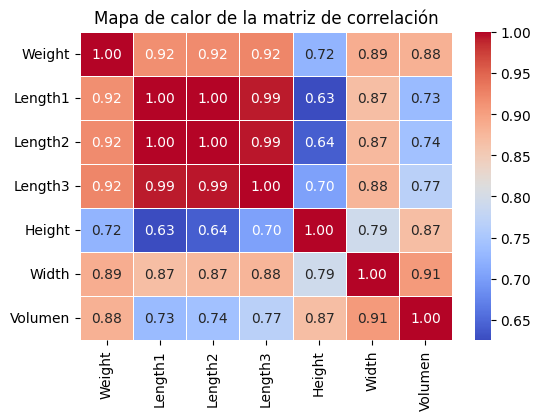

In [9]:
# Graficamos la matriz de correlaciones.
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Mapa de calor de la matriz de correlación")
plt.show()

#### Conclusión:
Según la matriz de correlación, todas las variables numéricas presentan una relación positiva con el peso del pez, lo que indica que al aumentar las dimensiones físicas del pez, su peso también tiende a aumentar. Sin embargo, el grado de correlación no es idéntico entre todas las variables: algunas longitudes presentan una correlación alta, mientras que otras variables muestran una relación moderada. Al incorporar el volumen, que combina altura y ancho del pez, se observa una correlación más fuerte con el peso, lo que sugiere que esta variable explica mejor la variabilidad del peso que las dimensiones consideradas de forma individual.

 3. Construye un modelo de regresión lineal que relacione el volumen y el peso de los
peces. Realiza una breve evaluación del modelo y grafícalo.

In [10]:
# Filtramos las columnas necesarias.
df_fish1 = df_fish[["Weight", "Volumen"]]

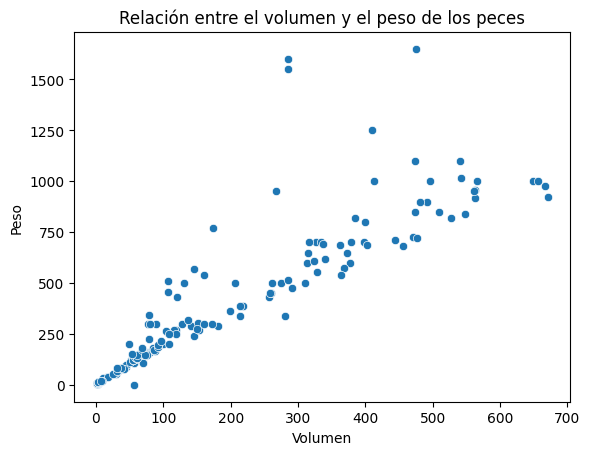

In [11]:
# Creamos una gráfica de dispersión.
sns.scatterplot(x="Volumen", y="Weight", data=df_fish1)
plt.title("Relación entre el volumen y el peso de los peces")
plt.xlabel("Volumen")
plt.ylabel("Peso")
plt.show()

#### Con el gráfico confirmamos que parece haber una correlación lineal positiva que verificaremos a continuación.

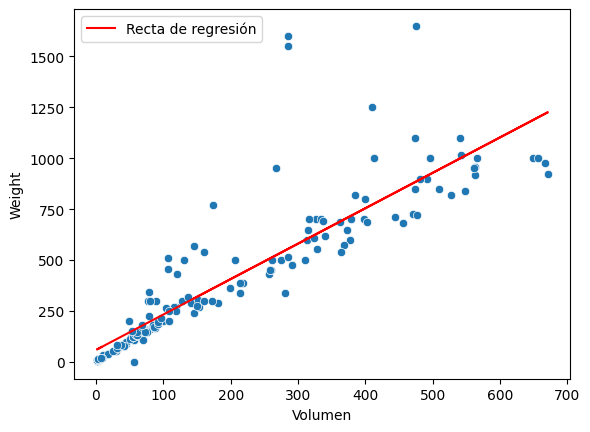

Pendiente: 1.73959569081126
Intercepto: 58.74007899977181
Error estándar: 0.07418602876018975
Coeficiente de correlación (r): 0.8819813276865701
Coeficiente de determinación (R²): 0.777891062387765


In [12]:
# Regresión lineal.
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_fish1["Volumen"], df_fish1["Weight"]
)

# Recta de regresión.
x_vals = df_fish1["Volumen"]
y_vals = intercept + slope * x_vals

sns.scatterplot(x="Volumen", y="Weight", data=df_fish1)
plt.plot(x_vals, y_vals, color='red', label='Recta de regresión')
plt.legend()
plt.show()

#Calculamos el coeficinte de determinación.
r2 = r_value ** 2

# Mostramos resultados.
print(f"Pendiente: {slope}")
print(f"Intercepto: {intercept}")
print(f"Error estándar: {std_err}")
print(f"Coeficiente de correlación (r): {r_value}")
print(f"Coeficiente de determinación (R²): {r2}")

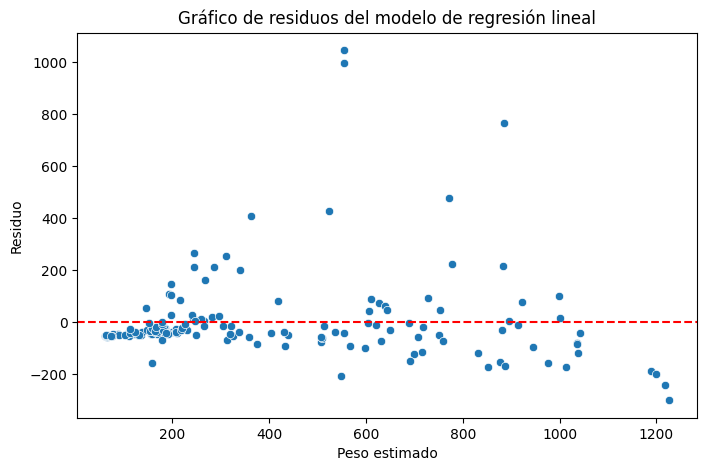

In [13]:
# Vamos a realizar un gráfico con los residuos.
# Valores predichos.
y_pred = intercept + slope * df_fish1["Volumen"]

# Residuo.
residuos = df_fish1["Weight"] - y_pred

# Gráfico de residuos.
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Peso estimado")
plt.ylabel("Residuo")
plt.title("Gráfico de residuos del modelo de regresión lineal")
plt.show()

#### Conclusión:
- El modelo de regresión lineal ajustado entre el volumen y el peso de los peces presenta una pendiente positiva de 1.74, lo que indica que el peso aumenta a medida que el volumen crece.
- El coeficiente de correlación obtenido (r ≈ 0.88) revela una relación lineal fuerte y positiva entre ambas variables, explicando cerca del 77% (R²) de la variabilidad del peso. Asimismo, el bajo error estándar del modelo sugiere un buen ajuste de los datos a la recta de regresión.
- El gráfico de residuos muestra una dispersión aleatoria alrededor del eje horizontal, lo que sugiere que el modelo lineal es adecuado.

En conjunto, estos resultados indican que el volumen es una variable adecuada para estimar el peso de los peces.

 4. ¿Qué sucede si aplicas el modelo anterior por separado a cada especie de peces?
Explica.

In [25]:
# Definimos variables predictorias.
X = df[['Volumen', 'Species']]
y = df['Weight']

In [26]:
# Codificamos Species con get_dummies.
X_encoded = pd.get_dummies(
    X,
    columns=['Species'],
    drop_first=True,
    dtype=float
)

In [27]:
# Agregamos una constante (intercepto).
X_encoded = sm.add_constant(X_encoded)

In [28]:
# Crearmos el modelo de regresión lineal.
model = sm.OLS(y, X_encoded).fit()

In [29]:
# Obtenemos los resultados y métricas.
results = model.summary()
predictions = model.predict(X_encoded)

mse = ((y - predictions) ** 2).mean()
emse = mse / ((y - y.mean()) ** 2).mean()
r2 = model.rsquared

print(results)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Error Mean Squared Explicado (EMSE): {emse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     191.5
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           9.58e-72
Time:                        15:50:27   Log-Likelihood:                -978.01
No. Observations:                 159   AIC:                             1972.
Df Residuals:                     151   BIC:                             1997.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -56.5012     31.07

#### Interpretación: 
- Coeficiente de determinación (R²): 0.90. El modelo explica el 90 % de la variabilidad del peso de los peces, lo que indica un muy buen ajuste global.
- Error Mean Squared Explicado (EMSE): 0.10. Aproximadamente el 10 % del error total no es explicado por el modelo.
- Volumen (coef = 1.83). Existe una relación positiva y altamente significativa entre el volumen y el peso del pez. Por cada unidad adicional de volumen, el peso aumenta en promedio 1.83 unidades, manteniendo constante la especie.
- Los coeficientes de las especies representan diferencias promedio de peso respecto a la especie de referencia. Species_Pike (coef = 447.66). Presenta el mayor impacto positivo y estadísticamente significativo del modelo. Species_Parkki, Species_Roach y Species_Smelt. No presentan coeficientes estadísticamente significativos, lo que sugiere que, al considerar el volumen, sus diferencias de peso no son concluyentes.
- Intercepto = −56.50. No tiene interpretación física directa, pero es necesario para el ajuste del modelo.
- En conclusión: El modelo que relaciona el peso de los peces con el volumen y la especie presenta un buen desempeño general, explicando el 90 % de la variabilidad del peso. El volumen resulta ser una variable altamente significativa, confirmando su fuerte relación con el peso. La inclusión de la especie permite identificar diferencias relevantes.

 5. Construye un modelo de regresión que relacione dos o más variables con el peso de
los peces. Realiza una breve evaluación del modelo.

In [35]:
# Definimos variables.
X = df[['Length3', 'Height', 'Species']]
y = df['Weight']

In [36]:
# Codificamos la especie (get_dummies).
X_encoded = pd.get_dummies(
    X,
    columns=['Species'],
    drop_first=True,
    dtype=float
)

In [37]:
# Agregamos la constante (intercepto).
X_encoded = sm.add_constant(X_encoded)

In [38]:
# Ajustamos el modelo.
model_multi = sm.OLS(y, X_encoded).fit()

In [39]:
# Obtenemos los resultados y métricas.
results = model_multi.summary()
predictions = model_multi.predict(X_encoded)

mse = ((y - predictions) ** 2).mean()
emse = mse / ((y - y.mean()) ** 2).mean()
r2 = model_multi.rsquared

print(results)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Error Mean Squared Explicado (EMSE): {emse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     265.1
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           1.96e-84
Time:                        15:54:40   Log-Likelihood:                -944.10
No. Observations:                 159   AIC:                             1906.
Df Residuals:                     150   BIC:                             1934.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -869.2938     63.75

#### Interpretación del modelo.
- Coeficiente de determinación (R²): 0.93. El 93 % de la variabilidad del peso de los peces es explicada por el modelo.
- Error Mean Squared Explicado (EMSE): 0.07. Solo el 7 % del error total no es explicado por el modelo, lo que refuerza su buen desempeño.
- Length3 (coef = 35.92). Existe una relación positiva y estadísticamente significativa entre la longitud total del pez y su peso. Por cada unidad adicional en Length3, el peso promedio del pez aumenta aproximadamente 35.9 unidades, manteniendo constantes las demás variables.
- Height (coef = 7.20). Si bien la relación es positiva, no resulta estadísticamente significativa. Esto sugiere que, una vez considerada la longitud y la especie, la altura no aporta información relevante adicional para explicar el peso.
- Intercepto = -869.29. Aunque no tiene interpretación física directa (peso negativo no es posible), es necesario para ajustar el modelo correctamente.
- Al comparar los resultados del punto 4 y el punto 5 se observan diferencias relevantes en el comportamiento de las especies Smelt(coef = 396.29) y Pike(coef = -217.59). En el punto 4, el efecto de cada especie sobre el peso refleja una diferencia promedio global, sin distinguir el aporte de las dimensiones físicas del pez. Sin embargo, en el punto 5, al incorporar variables como la longitud total y la altura, se evidencia que la especie Smelt mantiene un coeficiente positivo y estadísticamente significativo, lo que indica que su mayor peso no se explica únicamente por su tamaño, sino también por características propias de la especie. En contraste, la especie Pike presenta un coeficiente negativo, lo que sugiere que, a igual longitud y altura, los peces de esta especie tienden a pesar menos. Esto demuestra que el peso de Pike está más fuertemente asociado a sus dimensiones físicas que a la especie en sí, destacando la importancia de incluir variables morfológicas en el modelo.